# Activity 1 – Decision Tree Classification
**Dataset:** Seattle Weather | TC2004B — A01286400

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample
import warnings; warnings.filterwarnings('ignore')

## 1. Load Data & Class Balance Analysis

In [13]:
df = pd.read_csv('../../../data/s2/seattle-weather.csv').drop(columns=['date'])
X = df.drop(columns=['weather'])
y = df['weather']
counts_before = y.value_counts()
print('Class distribution before balancing:')
print(counts_before)
print(f'\nTotal samples: {len(y)}')
print('Dataset is imbalanced — rain/sun dominate, snow/drizzle are rare.')

Class distribution before balancing:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64

Total samples: 1461
Dataset is imbalanced — rain/sun dominate, snow/drizzle are rare.


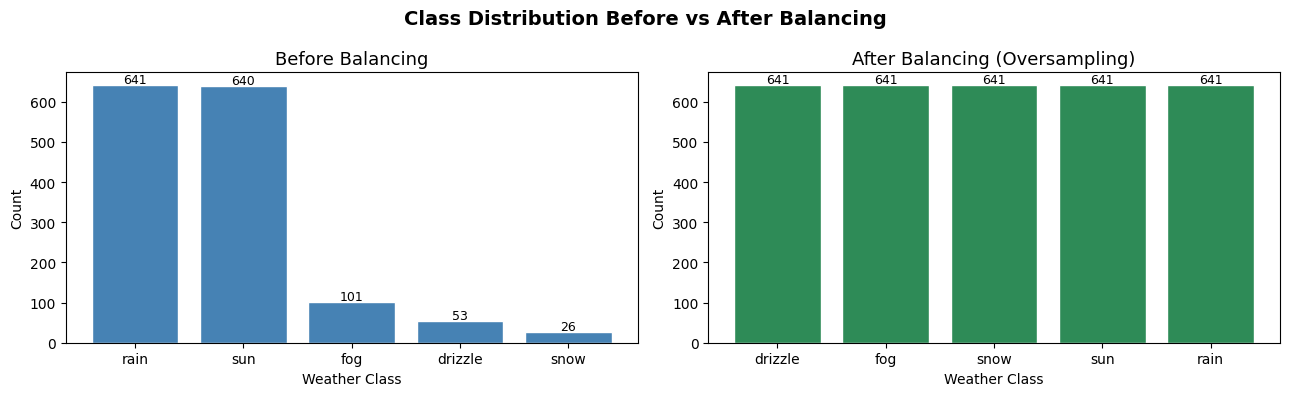

Balanced dataset size: 3205 samples (641 per class)


In [14]:
# Oversample minority classes to match the majority class count
df_combined = pd.concat([X, y], axis=1)
max_count = counts_before.max()
dfs = [resample(df_combined[df_combined['weather'] == lbl],
               replace=True, n_samples=max_count, random_state=42)
       for lbl in y.unique()]
df_bal = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
X_bal = df_bal.drop('weather', axis=1)
y_bal = df_bal['weather']
counts_after = y_bal.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(counts_before.index, counts_before.values, color='steelblue', edgecolor='white')
axes[0].set_title('Before Balancing', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)
axes[1].bar(counts_after.index, counts_after.values, color='seagreen', edgecolor='white')
axes[1].set_title('After Balancing (Oversampling)', fontsize=13)
axes[1].set_ylabel('Count')
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)
for ax in axes:
    ax.set_xlabel('Weather Class')
plt.suptitle('Class Distribution Before vs After Balancing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Balanced dataset size: {len(y_bal)} samples ({max_count} per class)')

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples (70/30 split)')

Train: 2243 samples | Test: 962 samples (70/30 split)


## 2. Default Decision Tree (No Hyperparameter Optimization)

In [16]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print(f'Tree depth: {dt.get_depth()} | Number of leaves: {dt.get_n_leaves()}')
print()
print(classification_report(y_test, y_pred))

Tree depth: 20 | Number of leaves: 251

              precision    recall  f1-score   support

     drizzle       0.90      1.00      0.95       193
         fog       0.95      0.99      0.97       192
        rain       0.96      0.96      0.96       192
        snow       0.98      1.00      0.99       193
         sun       0.97      0.81      0.89       192

    accuracy                           0.95       962
   macro avg       0.96      0.95      0.95       962
weighted avg       0.96      0.95      0.95       962



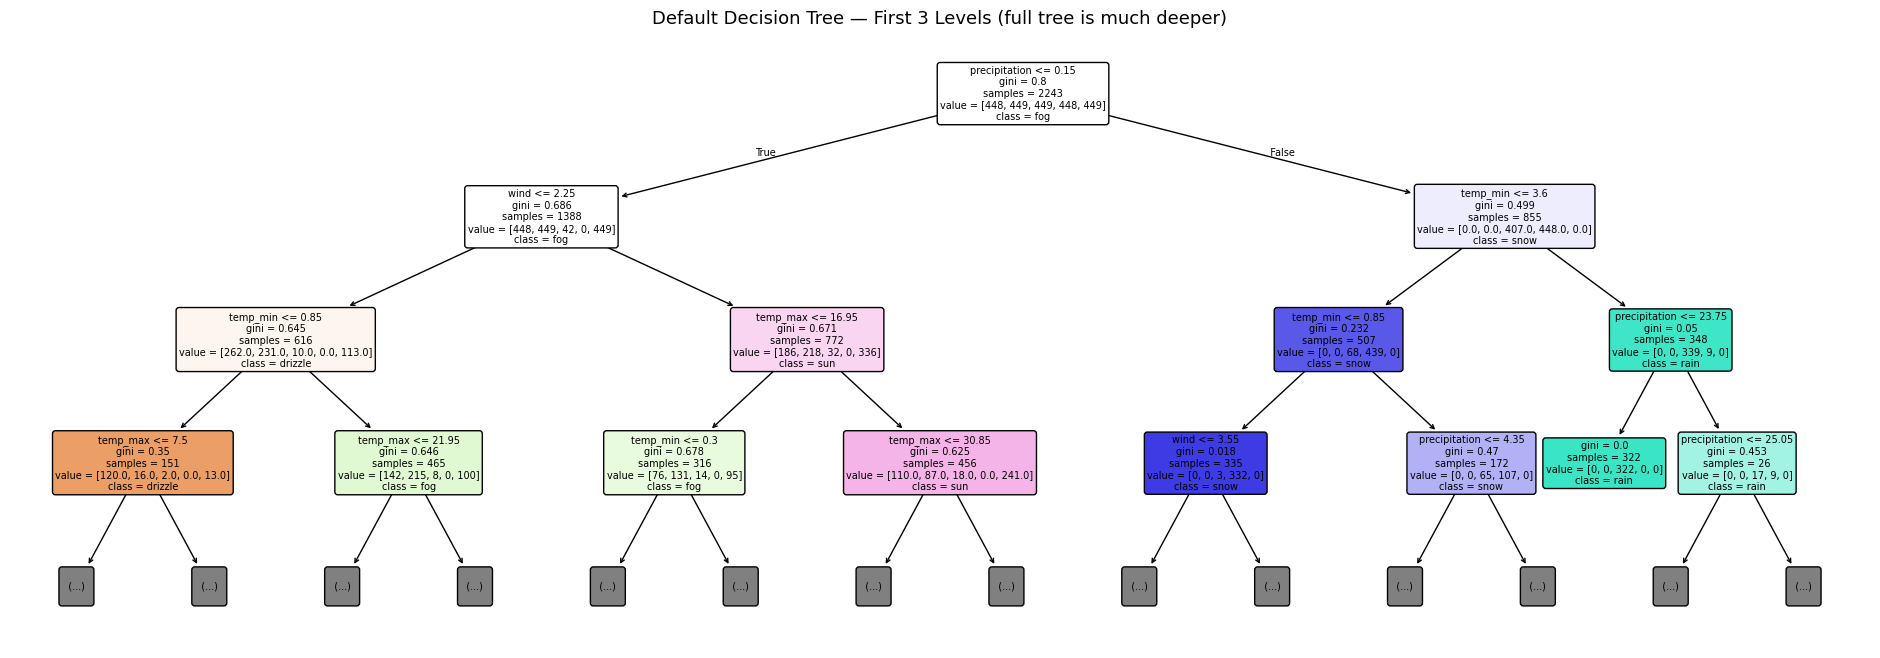

In [17]:
plt.figure(figsize=(24, 8))
plot_tree(dt, feature_names=X.columns.tolist(), class_names=dt.classes_,
          filled=True, max_depth=3, fontsize=7, rounded=True)
plt.title('Default Decision Tree — First 3 Levels (full tree is much deeper)', fontsize=13)
plt.show()

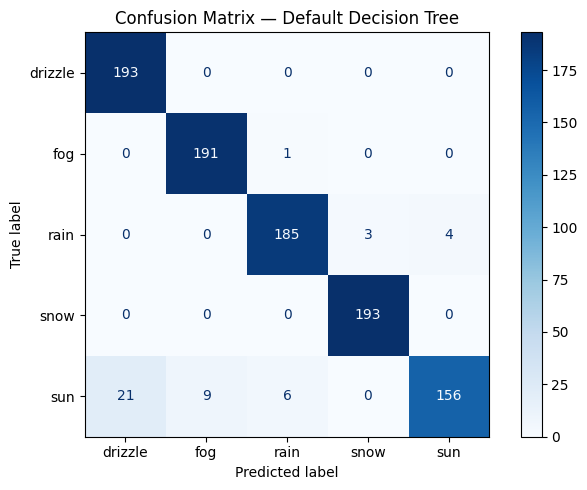

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — Default Decision Tree')
plt.tight_layout()
plt.show()

## 3. Optimized Decision Tree (GridSearchCV)

In [19]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'max_leaf_nodes': [None, 20, 50, 100, 150, 200, 250, 300]
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid,
                   cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print('Best hyperparameters:')
for k, v in grid.best_params_.items():
    print(f'  {k}: {v}')
print(f'Best cross-validation accuracy: {grid.best_score_:.4f}')

Best hyperparameters:
  max_depth: 20
  max_features: sqrt
  max_leaf_nodes: None
  min_samples_leaf: 1
  min_samples_split: 2
Best cross-validation accuracy: 0.9501


In [20]:
dt_opt = grid.best_estimator_
y_pred_opt = dt_opt.predict(X_test)
print(f'Optimized tree depth: {dt_opt.get_depth()} | Leaves: {dt_opt.get_n_leaves()}')
print()
print(classification_report(y_test, y_pred_opt))

Optimized tree depth: 20 | Leaves: 274

              precision    recall  f1-score   support

     drizzle       0.94      1.00      0.97       193
         fog       0.91      0.99      0.95       192
        rain       0.98      0.94      0.96       192
        snow       0.96      1.00      0.98       193
         sun       0.98      0.82      0.90       192

    accuracy                           0.95       962
   macro avg       0.95      0.95      0.95       962
weighted avg       0.95      0.95      0.95       962



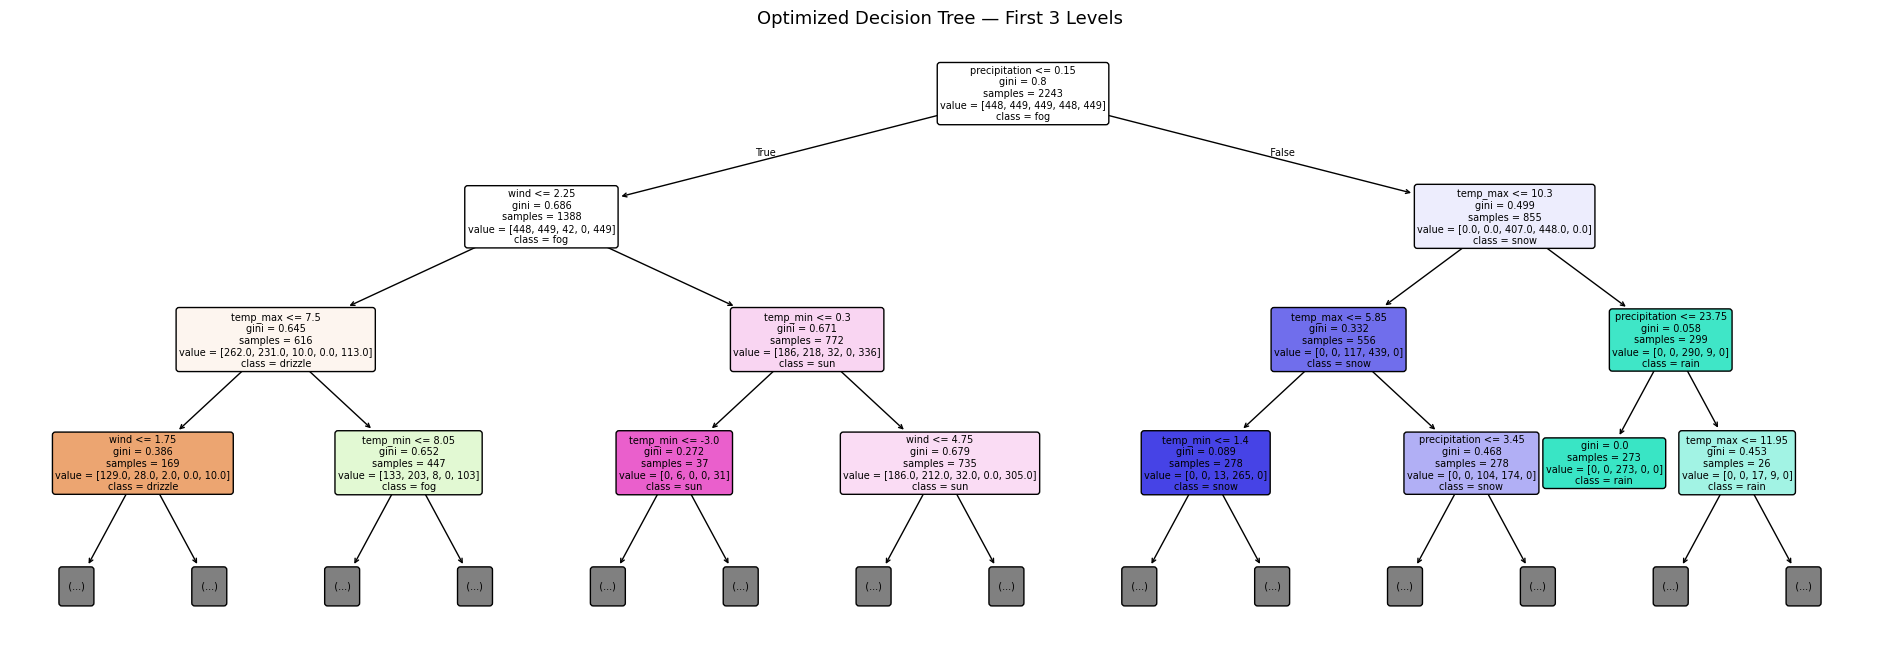

In [21]:
plt.figure(figsize=(24, 8))
plot_tree(dt_opt, feature_names=X.columns.tolist(), class_names=dt_opt.classes_,
          filled=True, max_depth=3, fontsize=7, rounded=True)
plt.title('Optimized Decision Tree — First 3 Levels', fontsize=13)
plt.show()

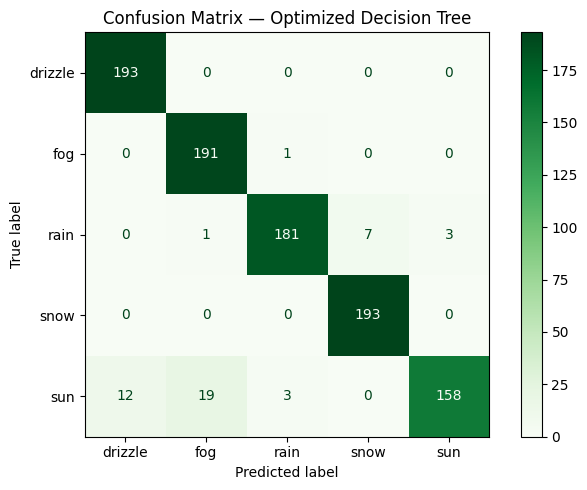

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt, ax=ax, cmap='Greens')
ax.set_title('Confusion Matrix — Optimized Decision Tree')
plt.tight_layout()
plt.show()

## 4. Comparison & Reflection

**Default DT:** Grows unconstrained, very deep tree, high risk of overfitting. The model memorizes training data.

**Optimized DT:** GridSearchCV used 5-fold cross-validation to find the best combination of:
- `max_depth` — limits tree depth, reduces overfitting
- `min_samples_split` — minimum samples required to split a node
- `min_samples_leaf` — minimum samples at each leaf → smoother decision boundaries
- `max_features` — number of features to consider at each split (randomness reduces variance)
- `max_leaf_nodes` — caps total leaves → enforces model simplicity

The optimized model is typically shallower, simpler, and generalizes better to unseen data. While the default tree may show higher training accuracy, the optimized tree achieves better or equal test accuracy with lower complexity, making it more interpretable and robust.